Assignment: 
 
Import Libraries: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Access Data from CSV file: 

In [2]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [3]:
matches.head()
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


Data Overview: 

In [4]:
matches.info()
matches.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

,id,season,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,0.025132,13.283069,3.350529
std,3464.478148,3.366895,0.156630,23.471144,3.387963
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,1.000000,146.000000,10.000000


BUSINESS-ORIENTED ANALYSIS QUESTIONS 

1. Match won by Maximum runs

In [5]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

2. Match won by maximum wickets.

In [6]:
matches.loc[matches['win_by_wickets'].idxmax()]

id                                                      3
season                                               2017
city                                               Rajkot
date                                           2017-04-07
team1                                       Gujarat Lions
team2                               Kolkata Knight Riders
toss_winner                         Kolkata Knight Riders
toss_decision                                       field
result                                             normal
dl_applied                                              0
winner                              Kolkata Knight Riders
win_by_runs                                             0
win_by_wickets                                         10
player_of_match                                   CA Lynn
venue              Saurashtra Cricket Association Stadium
umpire1                                       Nitin Menon
umpire2                                         CK Nandan
umpire3       

3. Match won by minimum runs.

In [7]:
matches[matches['win_by_runs'] > 0].sort_values(by='win_by_runs').head(1)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
755,11415,2019,Hyderabad,12/05/19,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Mumbai Indians,1,0,JJ Bumrah,Rajiv Gandhi Intl. Cricket Stadium,Nitin Menon,Ian Gould,Nigel Llong


4. Match won by minimum wickets

In [8]:
matches[matches['win_by_wickets'] > 0].sort_values(by='win_by_wickets').head(1)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
642,7900,2018,Hyderabad,12/04/18,Mumbai Indians,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,1,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",O Nandan,Nigel Llong,Vineet Kulkarni


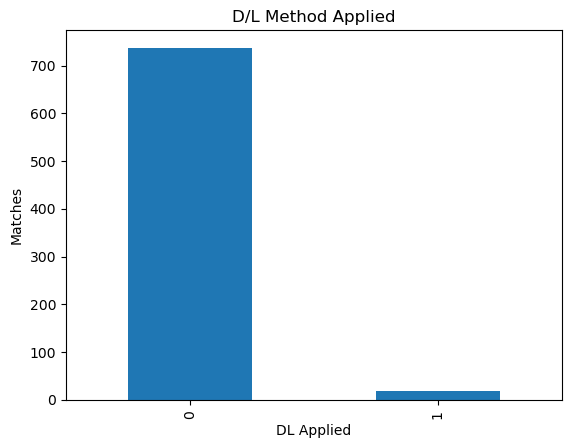

In [9]:
matches['dl_applied'].value_counts().plot(kind='bar')
plt.title("D/L Method Applied")
plt.xlabel("DL Applied")
plt.ylabel("Matches")
plt.show()

6. Matches held in each city 

In [10]:
matches['city'].value_counts()

city
Mumbai            101
Kolkata            77
Delhi              74
Bangalore          66
Hyderabad          64
Chennai            57
Jaipur             47
Chandigarh         46
Pune               38
Durban             15
Bengaluru          14
Visakhapatnam      13
Centurion          12
Ahmedabad          12
Rajkot             10
Mohali             10
Indore              9
Dharamsala          9
Johannesburg        8
Cuttack             7
Ranchi              7
Port Elizabeth      7
Cape Town           7
Abu Dhabi           7
Sharjah             6
Raipur              6
Kochi               5
Kanpur              4
Nagpur              3
Kimberley           3
East London         3
Bloemfontein        2
Name: count, dtype: int64

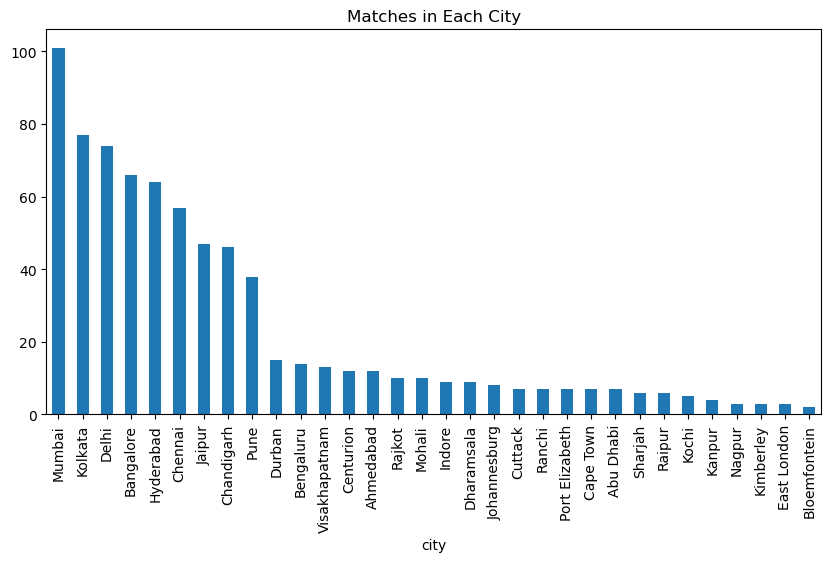

In [11]:
matches['city'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Matches in Each City")
plt.show()

7. Matches won by each team. 

In [12]:
matches['winner'].value_counts()


winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

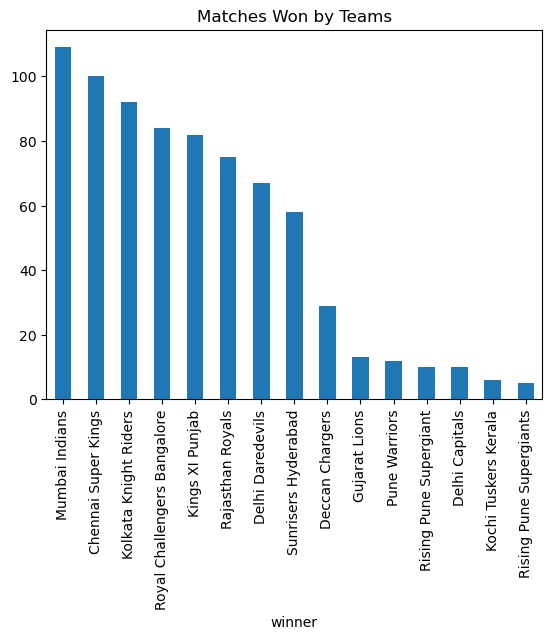

In [13]:
matches['winner'].value_counts().plot(kind='bar')
plt.title("Matches Won by Teams")
plt.show()

8. Matches held in each season.

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
Name: count, dtype: int64


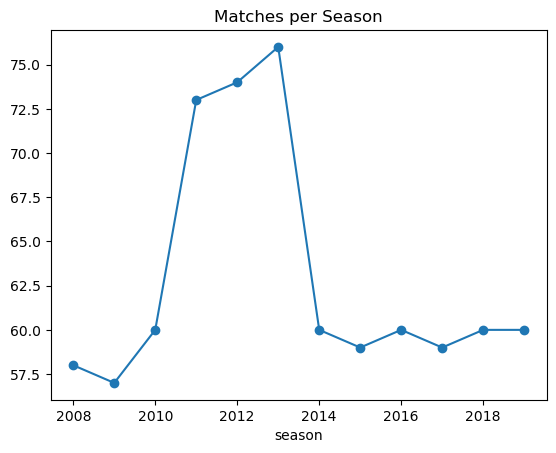

In [14]:
print(matches['season'].value_counts().sort_index())
matches['season' ].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Matches per Season")
plt.show()

9. Top 10 players by Man of the Match awards. 

In [15]:
matches['player_of_match'].value_counts().head(10)

player_of_match
CH Gayle          21
AB de Villiers    20
RG Sharma         17
MS Dhoni          17
DA Warner         17
YK Pathan         16
SR Watson         15
SK Raina          14
G Gambhir         13
MEK Hussey        12
Name: count, dtype: int64

10. Does winning the toss mean winning the match? 

True     393
False    363
Name: count, dtype: int64


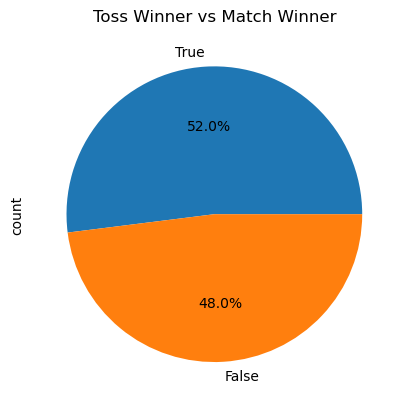

In [16]:
print((matches['toss_winner'] == matches['winner']).value_counts())

(matches['toss_winner' ] == matches['winner']). value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Toss Winner vs Match Winner")
plt.show()

11. Toss decision (bat or field)

toss_decision
field    463
bat      293
Name: count, dtype: int64


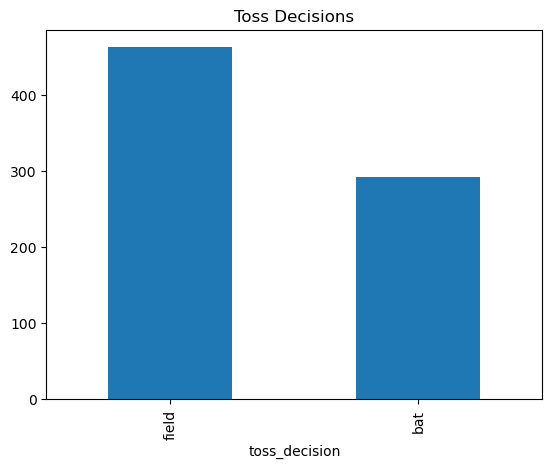

In [17]:
print(matches['toss_decision'].value_counts())

matches['toss_decision'].value_counts().plot(kind='bar')
plt.title("Toss Decisions")
plt.show()

12. D/L method applied each season

In [18]:
matches[matches['dl_applied']==1]['season'].value_counts()

season
2016    4
2009    3
2011    3
2018    3
2008    2
2015    2
2017    1
2014    1
Name: count, dtype: int64

13. Different match results

In [19]:
matches['result'].value_counts()

result
normal       743
tie            9
no result      4
Name: count, dtype: int64

14. Number of times each team won the toss

In [20]:
matches['toss_winner'].value_counts()

toss_winner
Mumbai Indians                 98
Kolkata Knight Riders          92
Chennai Super Kings            89
Royal Challengers Bangalore    81
Kings XI Punjab                81
Delhi Daredevils               80
Rajasthan Royals               80
Sunrisers Hyderabad            46
Deccan Chargers                43
Pune Warriors                  20
Gujarat Lions                  15
Delhi Capitals                 10
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
Name: count, dtype: int64

In [21]:
venue_runs = matches.groupby('venue')['win_by_runs'].sum()
venue_wickets = matches.groupby('venue')['win_by_wickets'].sum()

print("Best defending venue:", venue_runs.idxmax())
print("Best chasing venue:", venue_wickets.idxmax())

Best defending venue: M Chinnaswamy Stadium
Best chasing venue: Eden Gardens


Top 5 Defending Teams:
 winner
Mumbai Indians                 1866
Chennai Super Kings            1778
Royal Challengers Bangalore    1252
Kolkata Knight Riders          1086
Kings XI Punjab                 925
Name: win_by_runs, dtype: int64

Top 5 Chasing Teams:
 winner
Kolkata Knight Riders          351
Royal Challengers Bangalore    314
Mumbai Indians                 307
Chennai Super Kings            289
Delhi Daredevils               275
Name: win_by_wickets, dtype: int64


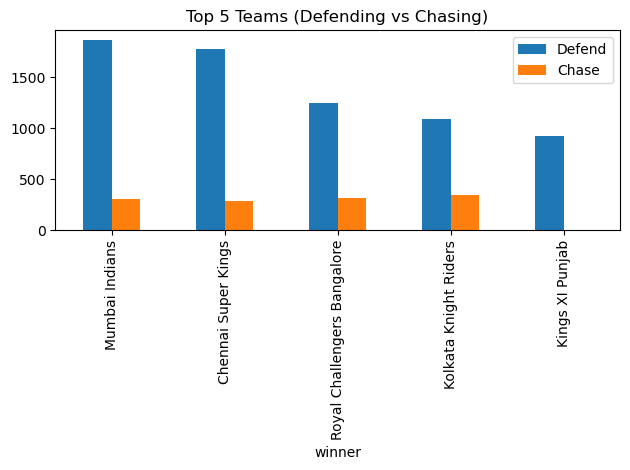

In [22]:
best_defending = matches.groupby('winner')['win_by_runs'].sum().sort_values(ascending=False)
best_chasing = matches.groupby('winner')['win_by_wickets'].sum().sort_values(ascending=False)

top5_def = best_defending.head(5)
top5_chase = best_chasing.head(5)

print("Top 5 Defending Teams:\n", top5_def)
print("\nTop 5 Chasing Teams:\n", top5_chase)

top5 = top5_def.to_frame('Defend')
top5['Chase'] = top5_chase

top5.plot(kind='bar')
plt.title("Top 5 Teams (Defending vs Chasing)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

17. Matches played in stadiums

venue
Eden Gardens                                            77
M Chinnaswamy Stadium                                   73
Wankhede Stadium                                        73
Feroz Shah Kotla                                        67
Rajiv Gandhi International Stadium, Uppal               56
MA Chidambaram Stadium, Chepauk                         49
Sawai Mansingh Stadium                                  47
Punjab Cricket Association Stadium, Mohali              35
Maharashtra Cricket Association Stadium                 21
Subrata Roy Sahara Stadium                              17
Dr DY Patil Sports Academy                              17
Kingsmead                                               15
Punjab Cricket Association IS Bindra Stadium, Mohali    14
SuperSport Park                                         12
Sardar Patel Stadium, Motera                            12
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     11
Brabourne Stadium                                 

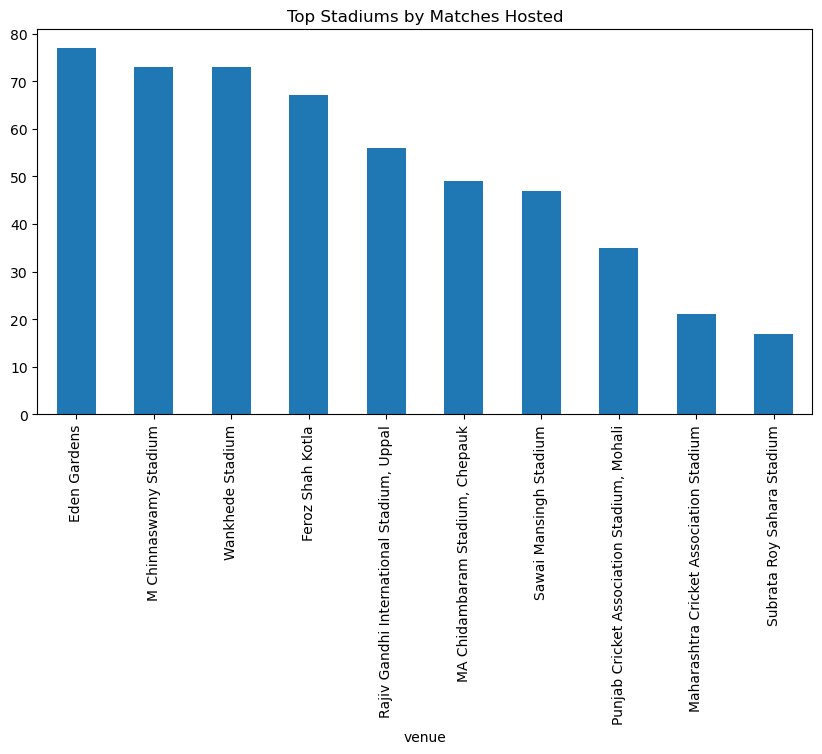

In [23]:
print(matches['venue'].value_counts())

matches['venue'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Stadiums by Matches Hosted")
plt.show()